Data loaded successfully.
Stationary data prepared (Shape: (137, 9)).

--- Calculating and Plotting Cross-Correlation Functions (CCF) ---


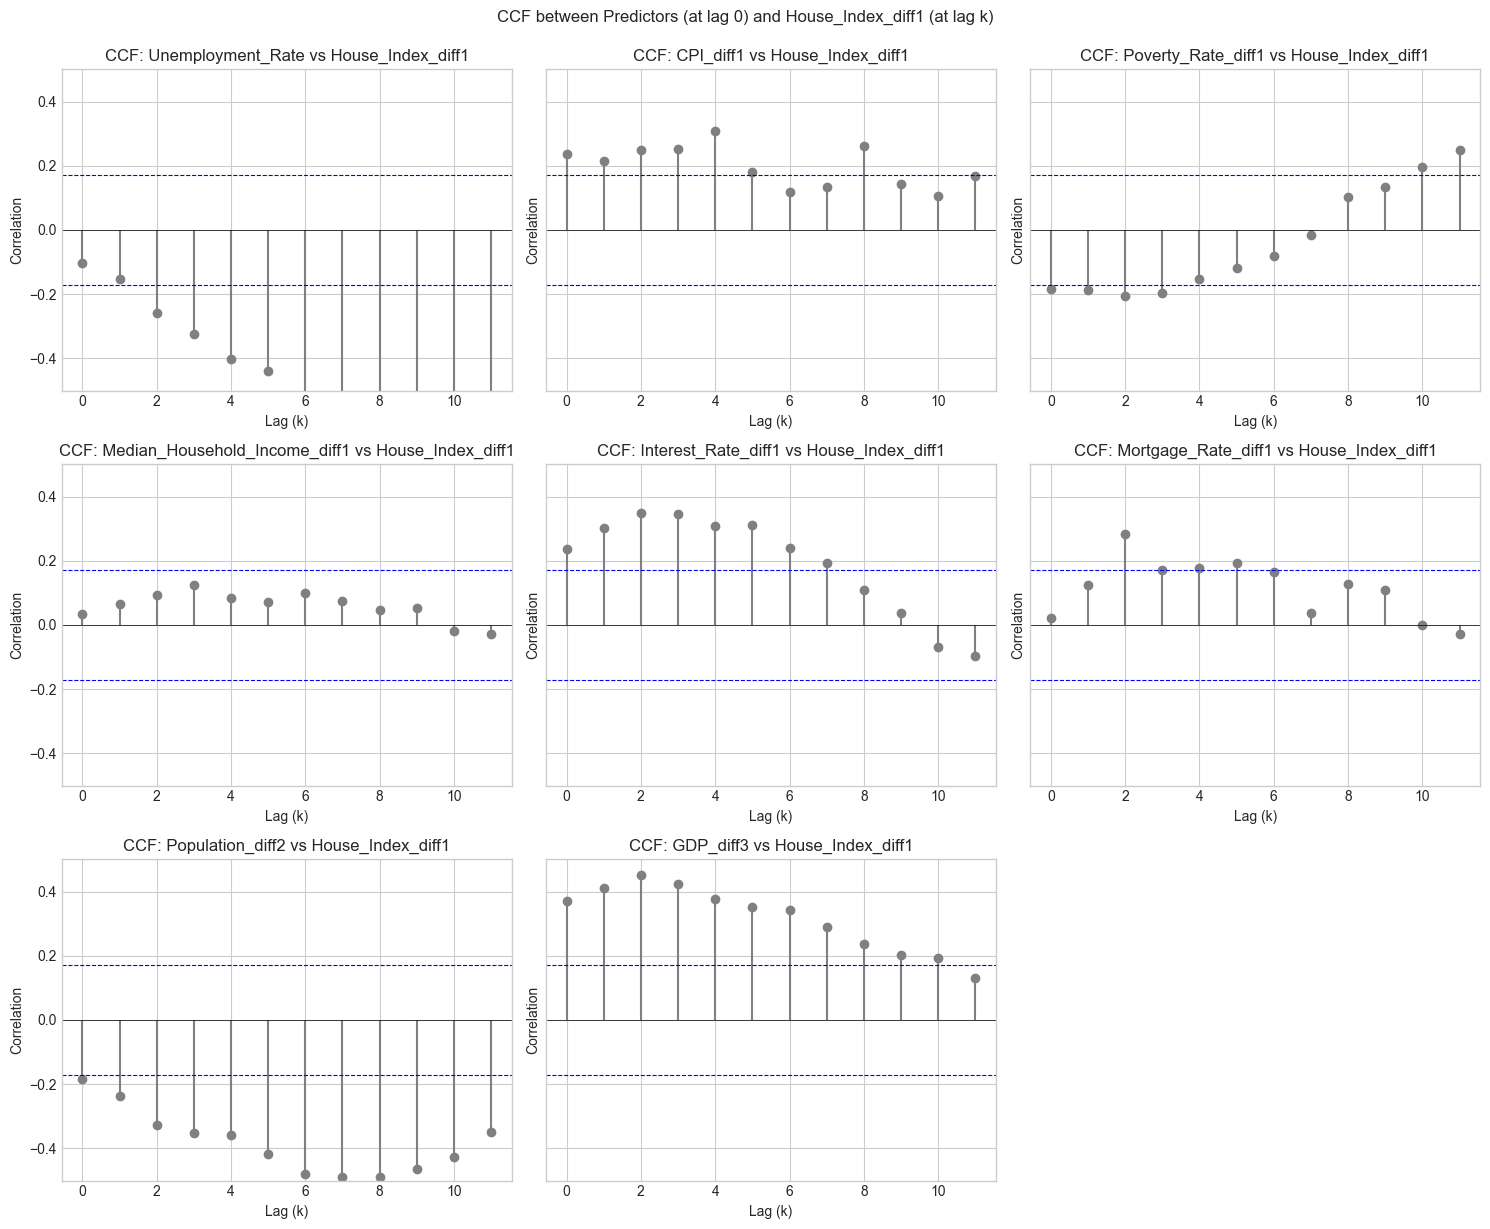


Interpretation Note:
 - Plot shows Correlation(Predictor[t], House_Index_diff1[t+k]).
 - Significant positive correlation at lag k > 0 suggests Predictor might lead the target by k quarters.
 - Significance bounds approx +/- 0.171

--- Performing Granger Causality Tests ---

Testing if 'Unemployment_Rate' Granger-causes 'House_Index_diff1' (maxlag=4):
  Lag 1: p-value = 0.3171 
  Lag 2: p-value = 0.5940 
  Lag 3: p-value = 0.1224 
  Lag 4: p-value = 0.0140 (Significant at 5%)
  -> Conclusion: Unemployment_Rate significantly Granger-causes House_Index_diff1 at one or more lags (up to 4).

Testing if 'CPI_diff1' Granger-causes 'House_Index_diff1' (maxlag=4):
  Lag 1: p-value = 0.1776 
  Lag 2: p-value = 0.3933 
  Lag 3: p-value = 0.0794 
  Lag 4: p-value = 0.0878 
  -> Conclusion: CPI_diff1 does not significantly Granger-cause House_Index_diff1 (up to lag 4).

Testing if 'Poverty_Rate_diff1' Granger-causes 'House_Index_diff1' (maxlag=4):
  Lag 1: p-value = 0.5288 
  Lag 2: p-value = 0.7

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid') # Ensure style is set

# --- Step 1: Load Data & Prepare Stationary Data ---
try:
    df_filled = pd.read_csv("DC_Master_Data_Filled.csv", parse_dates=['Date'], index_col='Date')
    df_filled = df_filled.asfreq('QS-JAN')
    print("Data loaded successfully.")

    df_stationary = pd.DataFrame(index=df_filled.index)

    # I(0) Variable
    df_stationary['Unemployment_Rate'] = df_filled['Unemployment_Rate']

    # I(1) Variables
    i1_vars = ['House_Index', 'CPI', 'Poverty_Rate', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate']
    for var in i1_vars:
        clean_var = var.strip()
        df_stationary[f'{clean_var}_diff1'] = df_filled[clean_var].diff(1)

    # I(2) Variable
    df_stationary['Population_diff2'] = df_filled['Population'].diff(2)

    # I(3) Variable
    df_stationary['GDP_diff3'] = df_filled['GDP'].diff(3)

    df_stationary.dropna(inplace=True)
    print(f"Stationary data prepared (Shape: {df_stationary.shape}).")

    target_var = 'House_Index_diff1'
    predictors = [col for col in df_stationary.columns if col != target_var]

    # --- Step 2: Cross-Correlation Functions (CCF) ---
    print("\n--- Calculating and Plotting Cross-Correlation Functions (CCF) ---")
    nlags_ccf = 12 # Look at correlations up to 12 lags (3 years)
    n_obs = len(df_stationary)
    conf_interval = 2 / np.sqrt(n_obs) # Approx 95% CI bounds

    num_predictors = len(predictors)
    # Determine grid size for subplots
    ncols_plot = 3
    nrows_plot = int(np.ceil(num_predictors / ncols_plot))

    fig_ccf, axes_ccf = plt.subplots(nrows=nrows_plot, ncols=ncols_plot, figsize=(ncols_plot * 5, nrows_plot * 4), sharey=True)
    axes_ccf = axes_ccf.flatten() # Flatten to easily iterate

    ccf_results = {}

    for i, predictor in enumerate(predictors):
        # Calculate CCF
        ccf_values = ccf(df_stationary[predictor], df_stationary[target_var], adjusted=True, nlags=nlags_ccf)
        ccf_results[predictor] = ccf_values

        # --- Debugging print statement ---
        # print(f"Predictor: {predictor}, CCF Length: {len(ccf_values)}")
        # ---------------------------------

        # Determine correct lag indices based on actual output length
        lag_indices = np.arange(len(ccf_values)) # Use actual length

        ax = axes_ccf[i]
        # Use the determined lag_indices for plotting
        ax.stem(lag_indices, ccf_values, linefmt='grey', markerfmt='o', basefmt=" ")
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axhline(conf_interval, color='blue', linestyle='--', linewidth=0.8)
        ax.axhline(-conf_interval, color='blue', linestyle='--', linewidth=0.8)
        ax.set_title(f'CCF: {predictor} vs {target_var}')
        ax.set_xlabel('Lag (k)')
        ax.set_ylabel('Correlation')
        ax.set_ylim(-0.5, 0.5) # Adjust ylim if needed
        ax.grid(True, axis='y')

    # Hide any unused subplots
    for j in range(i + 1, len(axes_ccf)):
        fig_ccf.delaxes(axes_ccf[j])

    plt.tight_layout()
    plt.suptitle(f'CCF between Predictors (at lag 0) and {target_var} (at lag k)', y=1.02)
    plt.show()

    print("\nInterpretation Note:")
    print(f" - Plot shows Correlation(Predictor[t], {target_var}[t+k]).")
    print(" - Significant positive correlation at lag k > 0 suggests Predictor might lead the target by k quarters.")
    print(f" - Significance bounds approx +/- {conf_interval:.3f}")


    # --- Step 3: Granger Causality Tests ---
    print("\n--- Performing Granger Causality Tests ---")
    max_lag_granger = 4 # Test up to 4 lags (1 year) - adjust if needed
    granger_results = {}

    for predictor in predictors:
        print(f"\nTesting if '{predictor}' Granger-causes '{target_var}' (maxlag={max_lag_granger}):")
        test_data = df_stationary[[target_var, predictor]]
        try:
            gc_result = grangercausalitytests(test_data, maxlag=max_lag_granger, verbose=False)
            granger_results[predictor] = {}
            significant_lags = []
            # Extract p-values for F-test
            for lag in range(1, max_lag_granger + 1):
                 p_value = gc_result[lag][0]['ssr_ftest'][1] # p-value from F-test
                 granger_results[predictor][lag] = p_value
                 is_significant = p_value < 0.05
                 significant_lags.append(is_significant)
                 print(f"  Lag {lag}: p-value = {p_value:.4f} {'(Significant at 5%)' if is_significant else ''}")
            # Summary for the variable
            if any(significant_lags):
                print(f"  -> Conclusion: {predictor} significantly Granger-causes {target_var} at one or more lags (up to {max_lag_granger}).")
            else:
                print(f"  -> Conclusion: {predictor} does not significantly Granger-cause {target_var} (up to lag {max_lag_granger}).")


        except Exception as e:
            print(f"  Could not perform Granger causality test for {predictor}: {e}")
            granger_results[predictor] = None

    print("\nInterpretation Note:")
    print(" - H0: Past values of Predictor do NOT Granger-cause Target.")
    print(" - A low p-value (< 0.05) suggests rejecting H0, meaning the predictor likely provides")
    print("   statistically significant information for forecasting the target variable at that lag.")


except FileNotFoundError:
    print("Error: The file 'DC_Master_Data_Filled.csv' was not found.")
except KeyError as e:
    print(f"Error: A column specified for differencing or testing was not found: {e}")
    print("Please check column names in DC_Master_Data_Filled.csv, including potential leading/trailing spaces.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 1: Load Data ---
try:
    df_filled = pd.read_csv("DC_Master_Data_Filled.csv", parse_dates=['Date'], index_col='Date')
    # Ensure the frequency is set correctly
    df_filled = df_filled.asfreq('QS-JAN')
    print("Data loaded successfully.")

    # --- Step 2: Create Stationary & Lagged Predictors ---
    df_predictors_stationary = pd.DataFrame(index=df_filled.index)

    # Create stationary versions needed for lagging
    df_predictors_stationary['Unemployment_Rate'] = df_filled['Unemployment_Rate'] # I(0)
    df_predictors_stationary['CPI_diff1'] = df_filled['CPI'].diff(1)
    df_predictors_stationary['Interest_Rate_diff1'] = df_filled['Interest_Rate'].diff(1)
    df_predictors_stationary['Mortgage_Rate_diff1'] = df_filled['Mortgage_Rate'].diff(1)
    df_predictors_stationary['GDP_diff3'] = df_filled['GDP'].diff(3)

    # Create lagged exogenous variables DataFrame
    df_exog = pd.DataFrame(index=df_filled.index)
    df_exog['Unemployment_Rate_L4'] = df_predictors_stationary['Unemployment_Rate'].shift(4)
    df_exog['CPI_diff1_L1'] = df_predictors_stationary['CPI_diff1'].shift(1)
    df_exog['Interest_Rate_diff1_L1'] = df_predictors_stationary['Interest_Rate_diff1'].shift(1)
    df_exog['Mortgage_Rate_diff1_L1'] = df_predictors_stationary['Mortgage_Rate_diff1'].shift(1)
    df_exog['GDP_diff3_L1'] = df_predictors_stationary['GDP_diff3'].shift(1)

    # Select target variable (original levels for SARIMAX)
    endog = df_filled['House_Index']

    # Combine and drop NaNs created by differencing AND lagging
    # Max lag is 4, max initial diff is 3 -> need to drop first 4 rows minimum
    final_df = pd.concat([endog, df_exog], axis=1)
    final_df.dropna(inplace=True)

    # Separate endog and exog again after dropping NaNs
    endog_aligned = final_df[endog.name]
    exog_aligned = final_df[df_exog.columns]

    print(f"Aligned endogenous and exogenous data prepared (Shape: {endog_aligned.shape}, {exog_aligned.shape}).")
    print("\n--- First 5 Rows of Exogenous Data for Model ---")
    print(exog_aligned.head())


    # --- Step 3: Fit SARIMAX Model ---
    # Using the order identified by auto_arima previously
    sarima_order = (3, 1, 2)
    seasonal_order = (1, 0, 0, 4)
    trend = 'c' # Include constant term

    print(f"\nFitting SARIMAX{sarima_order}x{seasonal_order} model with exogenous predictors...")

    model_sarimax = SARIMAX(endog=endog_aligned,
                            exog=exog_aligned,
                            order=sarima_order,
                            seasonal_order=seasonal_order,
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False)

    sarimax_results = model_sarimax.fit(disp=False) # disp=False hides convergence output
    print("SARIMAX model fitting complete.")

    # --- Step 4: Display SARIMAX Summary ---
    print("\n--- SARIMAX Model Summary ---")
    print(sarimax_results.summary())

    # --- Step 5: Check Residuals (Optional but Recommended) ---
    print("\nChecking SARIMAX residuals...")
    # Plot diagnostics
    # sarimax_results.plot_diagnostics(figsize=(15, 12))
    # plt.show()

    # Perform Ljung-Box test on residuals
    ljung_box_result = sm.stats.acorr_ljungbox(sarimax_results.resid, lags=[4, 8, 12], return_df=True) # Check multiple lags
    print("\nLjung-Box Test for Residual Autocorrelation:")
    print(ljung_box_result)
    print("H0: No serial correlation. High p-values (e.g., > 0.05) are desired.")


except FileNotFoundError:
    print("Error: The file 'DC_Master_Data_Filled.csv' was not found.")
except KeyError as e:
    print(f"Error: A column specified for differencing or lagging was not found: {e}")
    print("Please check column names in DC_Master_Data_Filled.csv, including potential leading/trailing spaces.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

Data loaded successfully.
Aligned endogenous and exogenous data prepared (Shape: (136,), (136, 5)).

--- First 5 Rows of Exogenous Data for Model ---
            Unemployment_Rate_L4  CPI_diff1_L1  Interest_Rate_diff1_L1  \
Date                                                                     
1991-01-01                   3.8          2.50                   -0.04   
1991-04-01                   3.8          0.90                   -1.20   
1991-07-01                   4.7          1.00                   -1.00   
1991-10-01                   4.9          0.80                   -0.09   
1992-01-01                   5.3          2.05                   -0.61   

            Mortgage_Rate_diff1_L1  GDP_diff3_L1  
Date                                              
1991-01-01                  0.1425       132.032  
1991-04-01                 -0.5400        75.150  
1991-07-01                 -0.1450       111.746  
1991-10-01                  0.0825       201.204  
1992-01-01               

In [9]:
import pandas as pd
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 1: Load Data ---
try:
    df = pd.read_csv("DC_Master_Data_Filled.csv", parse_dates=['Date'], index_col='Date')
    # Ensure the frequency is set correctly
    df = df.asfreq('QS-JAN')
    print("Data loaded successfully.")

    # --- Step 2: Create Recession Dummy ---
    # Define recession periods (start_date, end_date) based on NBER quarterly data
    recession_periods = [
        (pd.Timestamp('1990-07-01'), pd.Timestamp('1991-03-31')), # 1990 Q3 - 1991 Q1
        (pd.Timestamp('2001-01-01'), pd.Timestamp('2001-12-31')), # 2001 Q1 - 2001 Q4
        (pd.Timestamp('2007-10-01'), pd.Timestamp('2009-06-30')), # 2007 Q4 - 2009 Q2
        (pd.Timestamp('2019-10-01'), pd.Timestamp('2020-06-30'))  # 2019 Q4 - 2020 Q2
    ]

    df['Recession'] = 0 # Initialize with 0
    for start, end in recession_periods:
        df.loc[(df.index >= start) & (df.index <= end), 'Recession'] = 1

    print("Recession dummy created.")

    # --- Step 3: Create Hot Market Dummy (Percentile Method) ---
    # Calculate quarterly percentage change for GDP
    df['GDP_pct_change'] = df['GDP'].pct_change() * 100

    # Calculate the 85th percentile threshold for GDP growth
    # Drop the first NaN value from pct_change before calculating quantile
    growth_threshold_85 = df['GDP_pct_change'].dropna().quantile(0.85)
    print(f"GDP Growth 85th Percentile Threshold: {growth_threshold_85:.4f}%")

    # Create dummy: 1 if GDP growth > 85th percentile, 0 otherwise
    # Handle the initial NaN in pct_change by filling it with False before conversion
    df['Hot_Market'] = (df['GDP_pct_change'] > growth_threshold_85).fillna(False).astype(int)

    print("Hot Market dummy (85th Percentile) created.")

    # Remove the intermediate GDP % change column if desired
    # df = df.drop('GDP_pct_change', axis=1) # Keep it for now to verify


    # --- Step 4: Display Results ---
    print(f"\nDataFrame shape with new dummies: {df.shape}")

    print("\n--- Tail of DataFrame showing new dummies ---")
    print(df[['GDP_pct_change','Recession', 'Hot_Market']].tail(10)) # Show relevant columns

    print("\n--- Value Counts for Dummies ---")
    print("Recession Counts:")
    print(df['Recession'].value_counts())
    print("\nHot Market Counts:")
    print(df['Hot_Market'].value_counts())


except FileNotFoundError:
    print("Error: The file 'DC_Master_Data_Filled.csv' was not found.")
except KeyError as e:
    print(f"Error: Column not found: {e}")
    print("Please check column names.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

# --- Optional: Save the DataFrame with Dummies ---
output_file_with_dummies = 'DC_Master_Data_With_Dummies.csv'
df.reset_index().to_csv(output_file_with_dummies, index=False)
print(f"\nDataFrame with dummies saved to {output_file_with_dummies}")

Data loaded successfully.
Recession dummy created.
GDP Growth 85th Percentile Threshold: 1.7735%
Hot Market dummy (85th Percentile) created.

DataFrame shape with new dummies: (140, 12)

--- Tail of DataFrame showing new dummies ---
            GDP_pct_change  Recession  Hot_Market
Date                                             
2022-07-01        1.806649          0           1
2022-10-01        1.759538          0           0
2023-01-01        1.608729          0           0
2023-04-01        1.065573          0           0
2023-07-01        1.871805          0           1
2023-10-01        1.177323          0           0
2024-01-01        1.155961          0           0
2024-04-01        1.371730          0           0
2024-07-01        1.234461          0           0
2024-10-01        1.187918          0           0

--- Value Counts for Dummies ---
Recession Counts:
Recession
0    123
1     17
Name: count, dtype: int64

Hot Market Counts:
Hot_Market
0    119
1     21
Name: count,

In [10]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm # for Ljung-Box test
import warnings
import matplotlib.pyplot as plt # Keep for potential diagnostic plots

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 1: Load Data with Dummies ---
try:
    # Use the file uploaded by the user
    df_with_dummies = pd.read_csv("DC_Master_Data_With_Dummies.csv", parse_dates=['Date'], index_col='Date')
    # Ensure the frequency is set correctly
    df_with_dummies = df_with_dummies.asfreq('QS-JAN')
    print("Data with dummies loaded successfully.")
    print(f"DataFrame shape: {df_with_dummies.shape}")

    # --- Step 2: Define Endogenous and Exogenous Variables ---
    endog_var = 'House_Index'
    exog_vars = ['Recession', 'Hot_Market'] # Using the two new dummies

    # Check if columns exist
    if endog_var not in df_with_dummies.columns:
        raise KeyError(f"Endogenous variable '{endog_var}' not found.")
    for var in exog_vars:
        if var not in df_with_dummies.columns:
            raise KeyError(f"Exogenous variable '{var}' not found.")

    endog = df_with_dummies[endog_var]
    exog = df_with_dummies[exog_vars]

    # Ensure alignment (should be aligned if created together, but good practice)
    # No differencing applied here, SARIMAX handles 'd' internally
    # No lagging needed for dummies unless theory suggests lagged effect
    common_index = endog.index.intersection(exog.index)
    endog_aligned = endog.loc[common_index]
    exog_aligned = exog.loc[common_index]

    print(f"Aligned endogenous and exogenous data prepared (Shape: {endog_aligned.shape}, {exog_aligned.shape}).")

    # --- Step 3: Fit SARIMAX Model with Dummies ---
    # Using the order identified by auto_arima previously
    sarima_order = (3, 1, 2)
    seasonal_order = (1, 0, 0, 4)
    trend = 'c' # Include constant term

    print(f"\nFitting SARIMAX{sarima_order}x{seasonal_order} model with exogenous dummies...")

    model_sarimax_dummies = SARIMAX(endog=endog_aligned,
                                    exog=exog_aligned, # Use the dummy variables
                                    order=sarima_order,
                                    seasonal_order=seasonal_order,
                                    trend=trend,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)

    sarimax_dummies_results = model_sarimax_dummies.fit(disp=False) # disp=False hides convergence output
    print("SARIMAX model with dummies fitting complete.")

    # --- Step 4: Display SARIMAX Summary ---
    print("\n--- SARIMAX Model Summary (with Dummies) ---")
    print(sarimax_dummies_results.summary())

    # --- Step 5: Check Residuals ---
    print("\nChecking SARIMAX residuals...")
    # Perform Ljung-Box test on residuals
    # Check multiple lags (e.g., 4 quarters, 8 quarters, 12 quarters)
    lags_lb = [4, 8, 12]
    ljung_box_result_dummies = sm.stats.acorr_ljungbox(sarimax_dummies_results.resid, lags=lags_lb, return_df=True)
    print("\nLjung-Box Test for Residual Autocorrelation:")
    print(ljung_box_result_dummies)
    print("\nH0: No serial correlation.")
    print("High p-values (e.g., > 0.05) are desired (fail to reject H0).")

    # Optional: Plot diagnostics
    # print("\nGenerating diagnostic plots...")
    # sarimax_dummies_results.plot_diagnostics(figsize=(15, 12))
    # plt.show()


except FileNotFoundError:
    print("Error: The file 'DC_Master_Data_With_Dummies.csv' was not found.")
except KeyError as e:
    print(f"Error: A required column was not found: {e}")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

Data with dummies loaded successfully.
DataFrame shape: (140, 12)
Aligned endogenous and exogenous data prepared (Shape: (140,), (140, 2)).

Fitting SARIMAX(3, 1, 2)x(1, 0, 0, 4) model with exogenous dummies...
SARIMAX model with dummies fitting complete.

--- SARIMAX Model Summary (with Dummies) ---
                                     SARIMAX Results                                      
Dep. Variable:                        House_Index   No. Observations:                  140
Model:             SARIMAX(3, 1, 2)x(1, 0, [], 4)   Log Likelihood                -333.132
Date:                            Wed, 16 Apr 2025   AIC                            686.264
Time:                                    22:02:10   BIC                            715.092
Sample:                                01-01-1990   HQIC                           697.978
                                     - 10-01-2024                                         
Covariance Type:                              opg            

--- Preparing Data for SARIMAX Evaluation ---
Loading data from DC_Master_Data_With_Dummies.csv...
Data loaded successfully.
Dropped 4 rows due to NaNs from feature calculation.
Final aligned data shape for SARIMAX: (136, 4)
Test series (endog) starts from 2016-01-01. Shape: (36,)
Test series (exog) starts from 2016-01-01. Shape: (36, 3)
Performing 1-step ahead SARIMAX rolling forecast...
  Forecasting step 1/36 (Starting from Date: 2016-01-01)
  Forecasting step 11/36 (Starting from Date: 2018-07-01)
  Forecasting step 21/36 (Starting from Date: 2021-01-01)
  Forecasting step 31/36 (Starting from Date: 2023-07-01)
  Forecasting step 36/36 (Starting from Date: 2024-10-01)

--- 1-Step Ahead SARIMAX Forecast Evaluation Metrics ---
Mean Absolute Error (MAE):       3.251
Root Mean Squared Error (RMSE):  4.594
Mean Absolute Percentage Error (MAPE): 0.010
Directional Accuracy (%):        85.7
Performing 2-step ahead SARIMAX rolling forecast...
  Forecasting step 1/35 (Starting from Date: 201

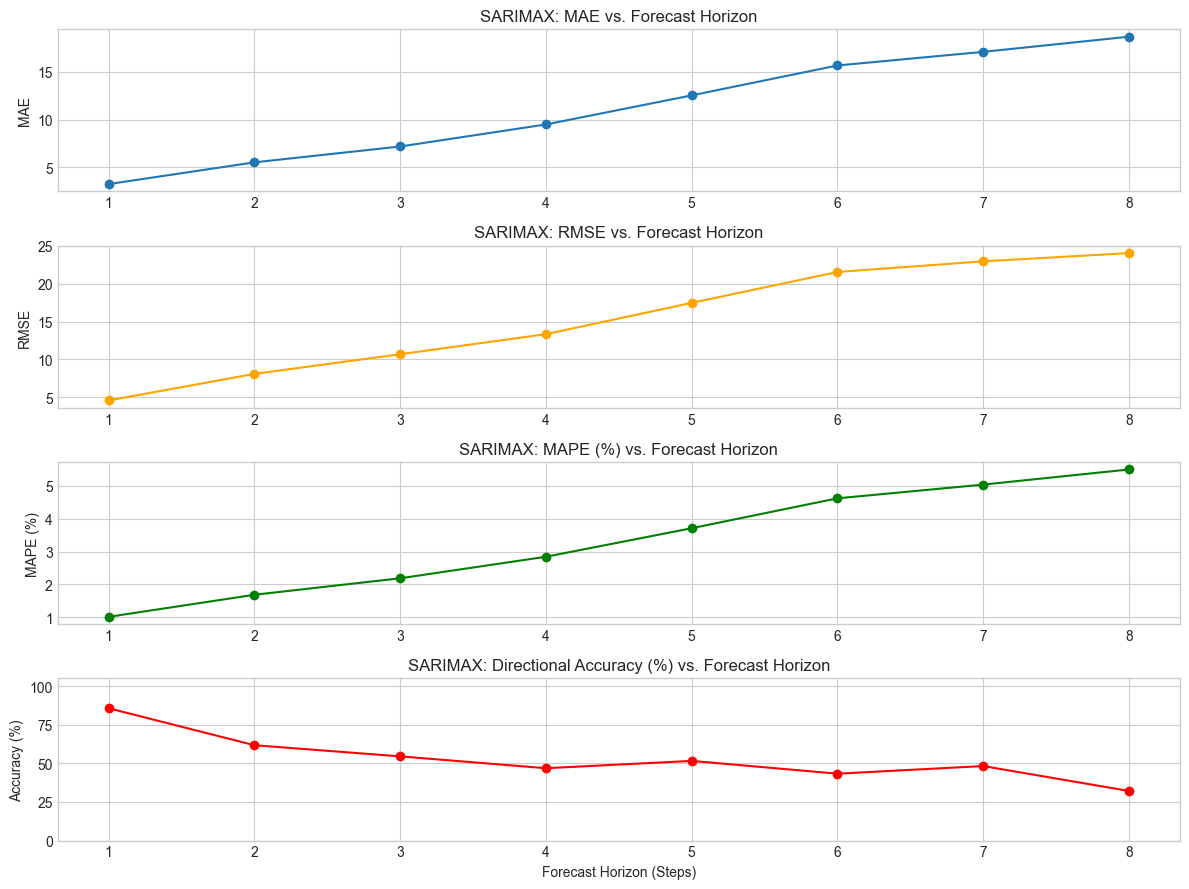

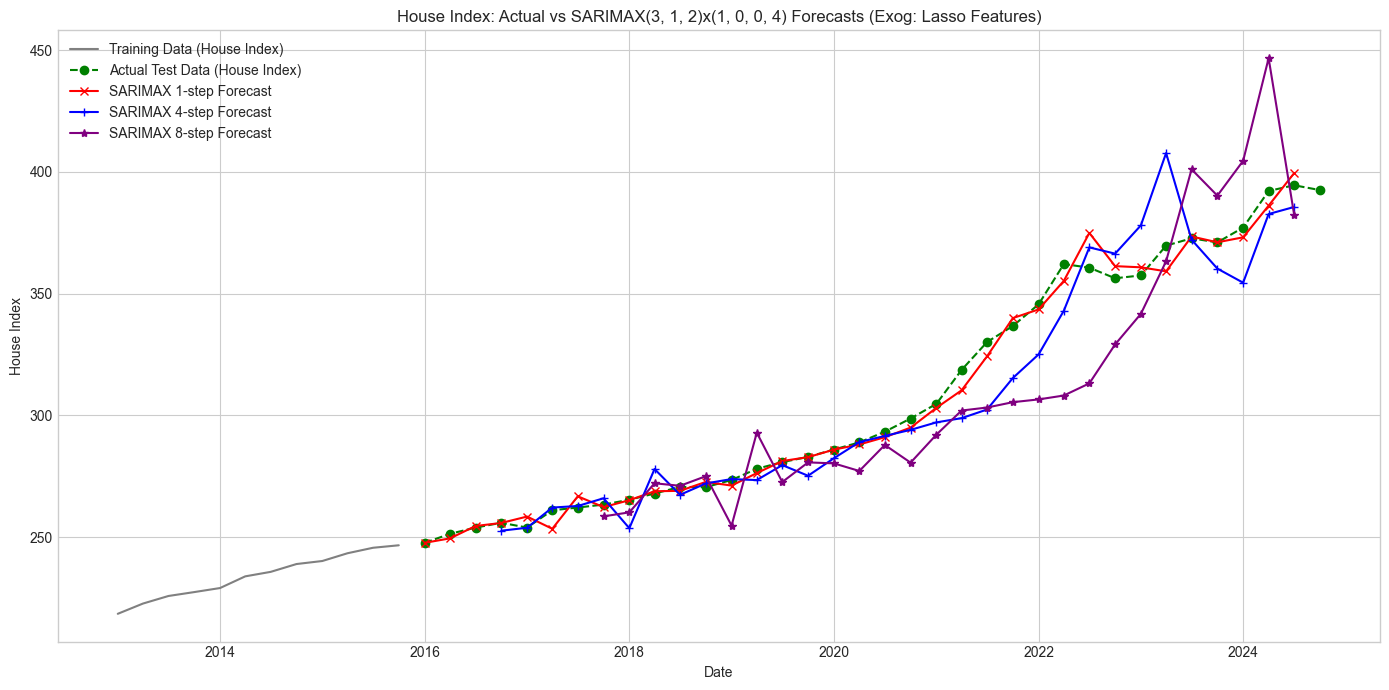

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings

# Suppress convergence and other warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Configuration ---
input_file = 'DC_Master_Data_With_Dummies.csv'
target_column = 'House_Index'
exog_cols_base = ['Recession', 'Hot_Market', 'GDP'] # Need GDP to calculate the lagged diff
test_start_date = '2016-01-01'
model_order = (3, 1, 2)
seasonal_order = (1, 0, 0, 4)
trend = 'c'
max_forecast_horizon = 8
series_end_date = '2024-10-01'

print(f"--- Preparing Data for SARIMAX Evaluation ---")
print(f"Loading data from {input_file}...")
try:
    # --- Step 1: Load and Prepare Data ---
    df_master = pd.read_csv(input_file, parse_dates=['Date'], index_col='Date')
    print("Data loaded successfully.")

    cols_needed = [target_column] + exog_cols_base
    if not all(col in df_master.columns for col in cols_needed):
        raise KeyError(f"One or more required columns ({cols_needed}) not found.")

    # Select necessary columns and filter date range
    df_pre_lasso = df_master[cols_needed].loc[df_master.index <= series_end_date].copy()

    # Calculate the exogenous variable derived from Lasso
    df_pre_lasso['GDP_diff3'] = df_pre_lasso['GDP'].diff(3)
    df_pre_lasso['GDP_diff3_L1'] = df_pre_lasso['GDP_diff3'].shift(1)

    # Define final exogenous variables list
    exog_cols_final = ['Recession', 'Hot_Market', 'GDP_diff3_L1']

    # Select endogenous and final exogenous variables
    endog_series_full = df_pre_lasso[target_column]
    exog_df_full = df_pre_lasso[exog_cols_final]

    # Combine and drop NaNs introduced by differencing/lagging (aligns endog and exog)
    df_sarimax_input = pd.concat([endog_series_full, exog_df_full], axis=1)
    initial_rows = df_sarimax_input.shape[0]
    df_sarimax_input.dropna(inplace=True)
    rows_dropped = initial_rows - df_sarimax_input.shape[0]
    print(f"Dropped {rows_dropped} rows due to NaNs from feature calculation.")
    print(f"Final aligned data shape for SARIMAX: {df_sarimax_input.shape}")

    # Separate final endogenous and exogenous variables
    endog_series_aligned = df_sarimax_input[target_column]
    exog_df_aligned = df_sarimax_input[exog_cols_final]

    # --- Define test period ---
    test_series_y = endog_series_aligned[endog_series_aligned.index >= test_start_date]
    test_series_X = exog_df_aligned[exog_df_aligned.index >= test_start_date]

    if test_series_y.empty:
        raise ValueError("Test series (endog) is empty. Check test_start_date and data range.")
    if len(test_series_y) != len(test_series_X):
         raise ValueError("Mismatch between lengths of endogenous and exogenous test series.")

    print(f"Test series (endog) starts from {test_start_date}. Shape: {test_series_y.shape}")
    print(f"Test series (exog) starts from {test_start_date}. Shape: {test_series_X.shape}")


    # --- Function to perform SARIMAX rolling forecast ---
    def perform_sarimax_rolling_forecast(series_y, df_X, test_y, test_X, start_date, steps_ahead, order, seasonal_order, trend):
        # Ensure indices match before slicing history
        history_y = series_y[series_y.index < start_date].copy()
        history_X = df_X[df_X.index < start_date].copy()

        predictions = []
        actuals = []

        print(f"Performing {steps_ahead}-step ahead SARIMAX rolling forecast...")

        # Determine the dates for which we can make an n-step forecast
        forecast_end_index_limit = len(test_y) - steps_ahead
        if forecast_end_index_limit < 0:
             print(f"Warning: Not enough data points in the test set to perform a {steps_ahead}-step ahead forecast.")
             return None, None

        forecast_start_dates = test_y.index[:forecast_end_index_limit + 1] # Dates *from which* forecasts are made

        for t, current_date in enumerate(forecast_start_dates):
            if t % 10 == 0 or t == len(forecast_start_dates) - 1:
                 print(f"  Forecasting step {t+1}/{len(forecast_start_dates)} (Starting from Date: {current_date.strftime('%Y-%m-%d')})")

            # Get exogenous variables for the forecast period (using actual future values)
            forecast_period_start_index = t + 1
            forecast_period_end_index = t + steps_ahead
            # Ensure indices are within the bounds of test_X
            if forecast_period_end_index >= len(test_X):
                 print(f"  Warning: Reached end of exogenous data, cannot get full {steps_ahead}-step future exog. Stopping horizon {steps_ahead}.")
                 break # Stop processing this horizon if we run out of future exog data

            future_exog = test_X.iloc[forecast_period_start_index : forecast_period_end_index + 1]

            if len(future_exog) != steps_ahead:
                 print(f"  Warning: Incorrect number of future exog rows retrieved ({len(future_exog)} vs {steps_ahead}). Stopping horizon {steps_ahead}.")
                 # This condition might indicate an off-by-one or boundary issue
                 # Let's double check the slicing logic. We need steps_ahead rows.
                 # Example: t=0, steps_ahead=2. Need test_X[1:3] (indices 1 and 2). Length is 2. Okay.
                 # Example: t=len-steps_ahead, steps_ahead=2. Need test_X[len-1 : len+1]. Last index is len-1.
                 # Correct indices should be from t+1 up to t+steps_ahead
                 idx_start = history_y.index.get_loc(current_date) + 1 # Index in original aligned series
                 future_exog_indices = df_X.index[idx_start : idx_start + steps_ahead]

                 if len(future_exog_indices) != steps_ahead:
                     print(f"  Corrected check: Incorrect number of future exog rows. Needed {steps_ahead}, got {len(future_exog_indices)}. Stopping.")
                     break # Stop if we can't get the required future exog

                 future_exog = df_X.loc[future_exog_indices]


            # Define and fit model using history up to current_date
            model = SARIMAX(
                endog=history_y, exog=history_X,
                order=order, seasonal_order=seasonal_order, trend=trend,
                enforce_stationarity=False, enforce_invertibility=False
            )
            results = model.fit(disp=False)

            # Get forecast using future exogenous values
            forecast_object = results.get_forecast(steps=steps_ahead, exog=future_exog)
            yhat = forecast_object.predicted_mean.iloc[steps_ahead-1] # Get the specific n-step ahead forecast
            predictions.append(yhat)

            # Store actual value that corresponds to our forecast horizon
            actual_date_index = t + steps_ahead - 1 # Index within test_y
            actual = test_y.iloc[actual_date_index]
            actuals.append(actual)

            # Update history (important: use original aligned series for slicing)
            next_hist_date = forecast_start_dates[t] # Date up to which history is used for this fit
            history_y = series_y[series_y.index <= next_hist_date]
            history_X = df_X[df_X.index <= next_hist_date]

        # Check if any predictions were made for this horizon
        if not predictions:
            print(f"  No predictions generated for horizon {steps_ahead}. Likely due to insufficient data.")
            return None, None

        # Align results using the date the forecast *was for*
        results_df = pd.DataFrame(
            {'Actual': actuals, f'Forecast ({steps_ahead}-step)': predictions},
            index=test_y.index[steps_ahead-1 : len(predictions) + steps_ahead - 1]
        )

        # --- Calculate Metrics ---
        mae = mean_absolute_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
        rmse = np.sqrt(mean_squared_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)']))
        if np.any(results_df['Actual'] == 0):
             non_zero_actuals = results_df['Actual'][results_df['Actual'] != 0]
             non_zero_preds = results_df[f'Forecast ({steps_ahead}-step)'][results_df['Actual'] != 0]
             mape = np.mean(np.abs((non_zero_actuals - non_zero_preds) / non_zero_actuals)) if len(non_zero_actuals) > 0 else np.nan
        else:
             mape = mean_absolute_percentage_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])

        # Directional Accuracy
        # Get original series (non-differenced) for previous actual value
        results_df['Actual_Previous'] = series_y.shift(1).reindex(results_df.index)
        results_df['Actual_Change'] = results_df['Actual'] - results_df['Actual_Previous']
        results_df['Predicted_Change'] = results_df[f'Forecast ({steps_ahead}-step)'] - results_df['Actual_Previous']
        valid_comparison = results_df[['Actual_Change', 'Predicted_Change']].dropna()
        correct_direction = (np.sign(valid_comparison['Actual_Change']) == np.sign(valid_comparison['Predicted_Change']))
        directional_accuracy = correct_direction.mean() * 100 if not correct_direction.empty else np.nan

        print(f"\n--- {steps_ahead}-Step Ahead SARIMAX Forecast Evaluation Metrics ---")
        print(f"Mean Absolute Error (MAE):       {mae:.3f}")
        print(f"Root Mean Squared Error (RMSE):  {rmse:.3f}")
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
        print(f"Directional Accuracy (%):        {directional_accuracy:.1f}")

        metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape*100, 'Directional Accuracy (%)': directional_accuracy}
        return results_df, metrics

    # --- Run forecasts for horizons 1 through max_forecast_horizon ---
    all_sarimax_results_dfs = {}
    all_sarimax_metrics = {}

    for h in range(1, max_forecast_horizon + 1):
        results_df, metrics = perform_sarimax_rolling_forecast(
            endog_series_aligned, exog_df_aligned, # Use aligned full series
            test_series_y, test_series_X,         # Use aligned test series
            test_start_date, h,
            model_order, seasonal_order, trend
        )
        if results_df is not None:
            all_sarimax_results_dfs[h] = results_df
            all_sarimax_metrics[h] = metrics
        else:
            print(f"Could not generate results for {h}-step ahead forecast. Stopping further horizons.")
            break

    # --- Consolidate and Compare Metrics ---
    if all_sarimax_metrics:
        metrics_comparison_df_sarimax = pd.DataFrame(all_sarimax_metrics).T
        metrics_comparison_df_sarimax.index.name = 'Forecast Horizon (Steps)'
        print("\n--- Comparison of SARIMAX Metrics Across Forecast Horizons ---")
        print(metrics_comparison_df_sarimax.to_markdown(floatfmt=".3f"))

        # --- Plot Metrics vs. Forecast Horizon ---
        plt.figure(figsize=(12, 9))
        plt.subplot(4, 1, 1)
        plt.plot(metrics_comparison_df_sarimax.index, metrics_comparison_df_sarimax['MAE'], marker='o')
        plt.title('SARIMAX: MAE vs. Forecast Horizon')
        plt.ylabel('MAE')
        plt.xticks(metrics_comparison_df_sarimax.index)
        plt.grid(True)
        plt.subplot(4, 1, 2)
        plt.plot(metrics_comparison_df_sarimax.index, metrics_comparison_df_sarimax['RMSE'], marker='o', color='orange')
        plt.title('SARIMAX: RMSE vs. Forecast Horizon')
        plt.ylabel('RMSE')
        plt.xticks(metrics_comparison_df_sarimax.index)
        plt.grid(True)
        plt.subplot(4, 1, 3)
        plt.plot(metrics_comparison_df_sarimax.index, metrics_comparison_df_sarimax['MAPE'], marker='o', color='green')
        plt.title('SARIMAX: MAPE (%) vs. Forecast Horizon')
        plt.ylabel('MAPE (%)')
        plt.xticks(metrics_comparison_df_sarimax.index)
        plt.grid(True)
        plt.subplot(4, 1, 4)
        plt.plot(metrics_comparison_df_sarimax.index, metrics_comparison_df_sarimax['Directional Accuracy (%)'], marker='o', color='red')
        plt.title('SARIMAX: Directional Accuracy (%) vs. Forecast Horizon')
        plt.ylabel('Accuracy (%)')
        plt.xlabel('Forecast Horizon (Steps)')
        plt.xticks(metrics_comparison_df_sarimax.index)
        plt.ylim(0, 105)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- Plot Actual vs Select Forecasts ---
        plt.figure(figsize=(14, 7))
        viz_start_date = '2013-01-01'
        historical_subset_y = endog_series_aligned[(endog_series_aligned.index < test_start_date) & (endog_series_aligned.index >= viz_start_date)]
        plt.plot(historical_subset_y.index, historical_subset_y, label='Training Data (House Index)', color='grey')
        plt.plot(test_series_y.index, test_series_y, label='Actual Test Data (House Index)', color='green', marker='o', linestyle='--')
        horizons_to_plot = [1, 4, 8]
        colors = ['red', 'blue', 'purple']
        markers = ['x', '+', '*']
        for i, h in enumerate(horizons_to_plot):
            if h in all_sarimax_results_dfs:
                plt.plot(all_sarimax_results_dfs[h].index, all_sarimax_results_dfs[h][f'Forecast ({h}-step)'],
                         label=f'SARIMAX {h}-step Forecast', color=colors[i % len(colors)],
                         marker=markers[i % len(markers)], linestyle='-')
        plt.title(f'House Index: Actual vs SARIMAX{model_order}x{seasonal_order} Forecasts (Exog: Lasso Features)')
        plt.xlabel('Date')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo metrics were generated for SARIMAX.")

except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found.")
except KeyError as e:
    print(f"Error: Problem accessing column: {e}")
except ValueError as e:
     print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred during analysis: {e}")